# 04. Estrategia de Arbitraje Energético
## TFM — Estimación de Precios de la Electricidad y Arbitraje Energético
### Jaime Cremades Castelló | CUNEF Universidad | 2026

Implementación de la estrategia de arbitraje con batería normalizada de 1 MWh.

**Parámetros de la batería:**
- Capacidad: 1 MWh | Potencia máxima: 0.2 MW (ratio C/5)
- Eficiencia de carga: η_ch = 0.95 | Eficiencia de descarga: η_dis = 0.95
- SoC mínimo: 10% | SoC máximo: 90% | SoC inicial: 50%

El problema de arbitraje se formula como un programa lineal con restricción explícita de no simultaneidad de carga y descarga, resuelto con el solver HiGHS de scipy.

**Input:** `predicciones_test.csv`
**Output:** `resultados_arbitraje.csv`, `beneficios_diarios.csv`


# TFM — Estrategia de Arbitraje Energético con Batería
## Jaime Cremades Castelló | CUNEF Universidad
### Capítulo 6 — Arbitraje con batería normalizada

Este notebook implementa la estrategia de arbitraje descrita en el capítulo 6.
Toma como input las predicciones de precio del notebook de modelos y calcula
el beneficio económico de cada modelo aplicado a una batería normalizada de 1 MWh.

**Parámetros de la batería (Khaloie, 2026):**
- Capacidad: 1 MWh
- Potencia máxima: 0.2 MW (ratio C/5)
- Eficiencia de carga: eta_ch = 0.95
- Eficiencia de descarga: eta_dis = 0.95
- SoC mínimo: 10%
- SoC máximo: 90%
- SoC inicial día 1: 50%
- SoC inicial resto de días: SoC final del día anterior

**Nota sobre la restriccion de no simultaneidad:**
La batería solo puede cargar o descargar en cada hora, nunca ambas a la vez.
Esta restricción se impone explícitamente mediante la condición
p_ch_h + p_dis_h <= P_MAX para cada hora h.


---
## 0. Configuración e imports

In [1]:
# ============================================================
# RUTA DEL ARCHIVO DE PREDICCIONES — generado por TFM_modelos.ipynb
# ============================================================
PREDICCIONES_PATH = 'Resultados/predicciones_test.csv'  # <- cambia si es necesario
# ============================================================

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import warnings
warnings.filterwarnings('ignore')

from scipy.optimize import linprog

print('Imports OK')

Imports OK


---
## 1. Parámetros de la batería

In [2]:
# Parámetros de la batería normalizada
# Referencia: Khaloie (2026)

E_CAP   = 1.0   # Capacidad total (MWh)
P_MAX   = 0.2   # Potencia máxima carga/descarga (MW) — ratio C/5
ETA_CH  = 0.95  # Eficiencia de carga (round-trip efficiency parcial)
ETA_DIS = 0.95  # Eficiencia de descarga (round-trip efficiency parcial)
SOC_MIN = 0.1   # Estado de carga mínimo (fracción de E_CAP)
SOC_MAX = 0.9   # Estado de carga máximo (fracción de E_CAP)
SOC_INI = 0.5   # Estado de carga inicial día 1 (valor neutral)
HORIZON = 24    # Horas por día

print('Parámetros de la batería:')
print(f'  Capacidad:           {E_CAP} MWh')
print(f'  Potencia máxima:     {P_MAX} MW (ratio C/{int(E_CAP/P_MAX)})')
print(f'  Eficiencia carga:    {ETA_CH}')
print(f'  Eficiencia descarga: {ETA_DIS}')
print(f'  Eficiencia RT:       {ETA_CH * ETA_DIS:.4f}')
print(f'  SoC mínimo:          {SOC_MIN*100:.0f}%')
print(f'  SoC máximo:          {SOC_MAX*100:.0f}%')
print(f'  SoC inicial:         {SOC_INI*100:.0f}%')

Parámetros de la batería:
  Capacidad:           1.0 MWh
  Potencia máxima:     0.2 MW (ratio C/5)
  Eficiencia carga:    0.95
  Eficiencia descarga: 0.95
  Eficiencia RT:       0.9025
  SoC mínimo:          10%
  SoC máximo:          90%
  SoC inicial:         50%


---
## 2. Carga de predicciones

In [3]:
# Cargar predicciones generadas por TFM_modelos.ipynb
df = pd.read_csv(PREDICCIONES_PATH, parse_dates=['datetime_test'])
df = df.sort_values('datetime_test').reset_index(drop=True)

print(f'Predicciones cargadas: {df.shape[0]} registros horarios')
print(f'Periodo: {df["datetime_test"].min().date()} — {df["datetime_test"].max().date()}')
print(f'Columnas: {list(df.columns)}')
df.head()

Predicciones cargadas: 9888 registros horarios
Periodo: 2025-01-01 — 2026-02-21
Columnas: ['datetime_test', 'precio_real', 'SARIMA', 'XGBoost', 'LSTM', 'N-BEATS', 'NBEATSx', 'BiGRU-KAN', 'BNN_mu', 'BNN_lower', 'BNN_upper']


,datetime_test,precio_real,SARIMA,XGBoost,LSTM,N-BEATS,NBEATSx,BiGRU-KAN,BNN_mu,BNN_lower,BNN_upper
0,2025-01-01 00:00:00,131.59,129.640520,125.210762,68.312057,70.962761,54.646820,60.975548,118.260289,89.117647,147.402931
1,2025-01-01 01:00:00,131.49,128.121608,127.000938,68.400665,62.518166,51.421413,55.575832,133.205740,110.353861,156.057620
2,2025-01-01 02:00:00,131.42,125.737754,131.102356,63.260113,56.125744,51.491936,49.286201,116.807616,79.527600,154.087632
3,2025-01-01 03:00:00,120.49,122.303925,128.669235,64.032242,48.135277,55.611919,48.338951,91.878715,48.747828,135.009602
4,2025-01-01 04:00:00,112.30,125.278675,124.331032,68.762268,53.669384,64.787361,60.389534,107.744953,80.204212,135.285693


In [4]:
# Modelos a evaluar
# BNN usa la media predictiva (mu) como estimacion puntual para las decisiones de arbitraje
MODELOS = {
    'SARIMA':    'SARIMA',
    'XGBoost':   'XGBoost',
    'LSTM':      'LSTM',
    'N-BEATS':   'N-BEATS',
    'NBEATSx':   'NBEATSx',
    'BiGRU-KAN': 'BiGRU-KAN',
    'BNN':       'BNN_mu'
}

# Agrupar por día
df['fecha'] = df['datetime_test'].dt.date
dias = df['fecha'].unique()
n_dias = len(dias)

print(f'Numero de dias en el test: {n_dias}')
print(f'Modelos a evaluar: {list(MODELOS.keys())}')

Numero de dias en el test: 415
Modelos a evaluar: ['SARIMA', 'XGBoost', 'LSTM', 'N-BEATS', 'NBEATSx', 'BiGRU-KAN', 'BNN']


---
## 3. Optimizador de arbitraje

In [5]:
def resolver_arbitraje(precios_pred, soc_inicial,
                        e_cap=E_CAP, p_max=P_MAX,
                        eta_ch=ETA_CH, eta_dis=ETA_DIS,
                        soc_min=SOC_MIN, soc_max=SOC_MAX):
    """
    Resuelve el problema de programacion lineal de arbitraje para un dia.

    Variables de decision:
        x = [p_ch_0, ..., p_ch_23, p_dis_0, ..., p_dis_23]  (48 variables)

    Funcion objetivo (linprog minimiza):
        min sum(precio_h * p_ch_h) - sum(precio_h * p_dis_h)
        equivalente a maximizar el beneficio neto de arbitraje.

    Restricciones:
        - Limites de potencia: 0 <= p_ch_h, p_dis_h <= P_MAX
        - No simultaneidad: p_ch_h + p_dis_h <= P_MAX  (una bateria solo puede
          cargar O descargar en cada hora, nunca ambas a la vez)
        - Limites de SoC: SOC_MIN <= SoC_h <= SOC_MAX para cada hora h
        - SoC se actualiza recursivamente: SoC_h = SoC_{h-1} + eta_ch*p_ch_h - p_dis_h/eta_dis

    Parametros:
        precios_pred: vector de 24 precios predichos (EUR/MWh)
        soc_inicial:  estado de carga inicial (fraccion de E_CAP)

    Returns:
        p_ch:      decisiones de carga (MW)
        p_dis:     decisiones de descarga (MW)
        soc_final: estado de carga al final del dia (fraccion de E_CAP)
    """
    H = HORIZON

    # Vector de costes para linprog (minimiza c @ x)
    # Beneficio = sum(precio * p_dis) - sum(precio * p_ch)
    # Para minimizar el negativo: c = [precios, -precios]
    c = np.concatenate([precios_pred, -precios_pred])

    # Limites de variables: p_ch y p_dis entre 0 y P_MAX
    bounds = [(0, p_max)] * H + [(0, p_max)] * H

    # Restricciones de desigualdad (A_ub @ x <= b_ub)
    A_ub = []
    b_ub = []

    for h in range(H):
        # Restriccion de SoC maximo en hora h:
        # soc_ini + sum_{i=0}^{h}(eta_ch*p_ch_i - p_dis_i/eta_dis) <= soc_max
        row_ch  = np.zeros(H)
        row_dis = np.zeros(H)
        row_ch[:h+1]  =  eta_ch
        row_dis[:h+1] = -1.0 / eta_dis
        A_ub.append(np.concatenate([row_ch, row_dis]))
        b_ub.append((soc_max - soc_inicial) * e_cap)

        # Restriccion de SoC minimo en hora h:
        # soc_ini + sum_{i=0}^{h}(eta_ch*p_ch_i - p_dis_i/eta_dis) >= soc_min
        A_ub.append(np.concatenate([-row_ch, -row_dis]))
        b_ub.append(-(soc_min - soc_inicial) * e_cap)

        # Restriccion de no simultaneidad: p_ch_h + p_dis_h <= P_MAX
        # Garantiza que en cada hora la bateria solo carga o descarga
        row_nosim = np.zeros(2 * H)
        row_nosim[h]     = 1.0  # p_ch_h
        row_nosim[H + h] = 1.0  # p_dis_h
        A_ub.append(row_nosim)
        b_ub.append(p_max)

    A_ub = np.array(A_ub)
    b_ub = np.array(b_ub)

    # Resolver LP con metodo HiGHS
    result = linprog(c, A_ub=A_ub, b_ub=b_ub, bounds=bounds, method='highs')

    if result.success:
        p_ch  = result.x[:H]
        p_dis = result.x[H:]
        soc_final = soc_inicial + (eta_ch * p_ch.sum() - p_dis.sum() / eta_dis) / e_cap
        soc_final = np.clip(soc_final, soc_min, soc_max)
    else:
        # Si el LP no converge, dia sin operacion
        p_ch      = np.zeros(H)
        p_dis     = np.zeros(H)
        soc_final = soc_inicial

    return p_ch, p_dis, soc_final


def calcular_beneficio_dia(precios_reales, p_ch, p_dis):
    """
    Calcula el beneficio real de un dia de arbitraje.
    Las decisiones se toman con precios predichos (p_ch, p_dis),
    pero el beneficio se evalua con precios reales de mercado.
    """
    return np.sum(precios_reales * p_dis) - np.sum(precios_reales * p_ch)


print('Funciones de arbitraje definidas')
print('Restriccion de no simultaneidad: activa')

Funciones de arbitraje definidas
Restriccion de no simultaneidad: activa


---
## 4. Benchmark de predicción perfecta y evaluación de modelos

In [6]:
print('Calculando benchmark de prediccion perfecta...')

benchmark_diario = []
dias_validos     = []
soc = SOC_INI

for dia in dias:
    df_dia = df[df['fecha'] == dia]
    if len(df_dia) != 24:
        continue
    dias_validos.append(dia)
    precios_reales = df_dia['precio_real'].values
    p_ch, p_dis, soc = resolver_arbitraje(precios_reales, soc)
    beneficio = calcular_beneficio_dia(precios_reales, p_ch, p_dis)
    benchmark_diario.append(beneficio)

benchmark_diario = np.array(benchmark_diario)
benchmark_total  = benchmark_diario.sum()

print(f'Benchmark de prediccion perfecta:')
print(f'  Beneficio total:        {benchmark_total:.2f} EUR/MWh')
print(f'  Beneficio medio diario: {benchmark_diario.mean():.2f} EUR/MWh/dia')
print(f'  Dias validos:           {len(dias_validos)}')

Calculando benchmark de prediccion perfecta...
Benchmark de prediccion perfecta:
  Beneficio total:        24877.48 EUR/MWh
  Beneficio medio diario: 61.27 EUR/MWh/dia
  Dias validos:           406


In [7]:
print('Evaluando modelos...')

resultados_arbitraje = {}

for nombre_modelo, col_pred in MODELOS.items():
    # Verificar que la columna existe en el CSV
    if col_pred not in df.columns:
        print(f'  {nombre_modelo}: columna {col_pred} no encontrada, omitiendo')
        continue

    print(f'  Procesando {nombre_modelo}...')
    beneficios_diarios = []
    soc = SOC_INI

    for dia in dias_validos:
        df_dia = df[df['fecha'] == dia]
        if len(df_dia) != 24:
            continue
        precios_pred   = df_dia[col_pred].values
        precios_reales = df_dia['precio_real'].values
        p_ch, p_dis, soc = resolver_arbitraje(precios_pred, soc)
        beneficio = calcular_beneficio_dia(precios_reales, p_ch, p_dis)
        beneficios_diarios.append(beneficio)

    beneficios_diarios = np.array(beneficios_diarios)
    beneficio_total    = beneficios_diarios.sum()
    eficiencia         = (beneficio_total / benchmark_total) * 100

    resultados_arbitraje[nombre_modelo] = {
        'B_total':      beneficio_total,
        'B_diario_med': beneficios_diarios.mean(),
        'B_diario_std': beneficios_diarios.std(),
        'eficiencia':   eficiencia,
        'B_diario':     beneficios_diarios
    }
    print(f'    B_total: {beneficio_total:.2f} EUR/MWh | Eficiencia: {eficiencia:.1f}%')

print('\nEvaluacion completada')

Evaluando modelos...
  Procesando SARIMA...
    B_total: 21900.87 EUR/MWh | Eficiencia: 88.0%
  Procesando XGBoost...
    B_total: 22822.31 EUR/MWh | Eficiencia: 91.7%
  Procesando LSTM...
    B_total: 19183.07 EUR/MWh | Eficiencia: 77.1%
  Procesando N-BEATS...
    B_total: 21417.17 EUR/MWh | Eficiencia: 86.1%
  Procesando NBEATSx...
    B_total: 19744.72 EUR/MWh | Eficiencia: 79.4%
  Procesando BiGRU-KAN...
    B_total: 20129.61 EUR/MWh | Eficiencia: 80.9%
  Procesando BNN...
    B_total: 22415.80 EUR/MWh | Eficiencia: 90.1%

Evaluacion completada


---
## 5. Tabla comparativa de métricas económicas

In [8]:
rows = []
for modelo, res in resultados_arbitraje.items():
    rows.append({
        'Modelo':               modelo,
        'B_total (EUR/MWh)':    round(res['B_total'], 2),
        'B_diario_med (EUR/MWh)': round(res['B_diario_med'], 2),
        'B_diario_std (EUR/MWh)': round(res['B_diario_std'], 2),
        'Eficiencia (%)':       round(res['eficiencia'], 1)
    })

rows.append({
    'Modelo':               'Benchmark (perfecta)',
    'B_total (EUR/MWh)':    round(benchmark_total, 2),
    'B_diario_med (EUR/MWh)': round(benchmark_diario.mean(), 2),
    'B_diario_std (EUR/MWh)': round(benchmark_diario.std(), 2),
    'Eficiencia (%)':       100.0
})

tabla_arb = pd.DataFrame(rows).set_index('Modelo')

print('\n=== TABLA COMPARATIVA DE METRICAS ECONOMICAS ===')
print(tabla_arb.to_string())
print(f'\nMejor modelo por beneficio total: {tabla_arb["B_total (EUR/MWh)"][:-1].idxmax()}')
print(f'Mejor modelo por eficiencia:      {tabla_arb["Eficiencia (%)"][:-1].idxmax()}')


=== TABLA COMPARATIVA DE METRICAS ECONOMICAS ===
                      B_total (EUR/MWh)  B_diario_med (EUR/MWh)  B_diario_std (EUR/MWh)  Eficiencia (%)
Modelo                                                                                                 
SARIMA                         21900.87                   53.94                   29.59            88.0
XGBoost                        22822.31                   56.21                   29.02            91.7
LSTM                           19183.07                   47.25                   29.86            77.1
N-BEATS                        21417.17                   52.75                   29.22            86.1
NBEATSx                        19744.72                   48.63                   32.34            79.4
BiGRU-KAN                      20129.61                   49.58                   30.61            80.9
BNN                            22415.80                   55.21                   30.32            90.1
Benchmark (per

---
## 6. Visualización de resultados

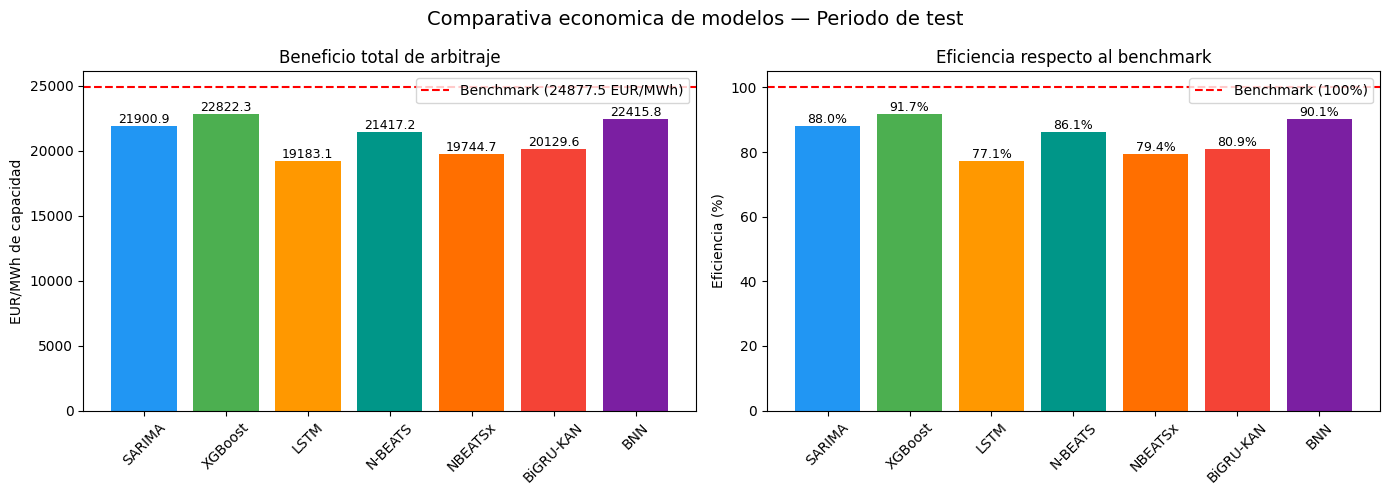

Grafico guardado como comparativa_arbitraje.png


In [9]:
colores = ['#2196F3', '#4CAF50', '#FF9800', '#009688', '#FF6F00', '#F44336', '#7B1FA2']
modelos_lista = list(resultados_arbitraje.keys())

# Grafico 1 — Beneficio total y eficiencia por modelo
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

beneficios  = [resultados_arbitraje[m]['B_total'] for m in modelos_lista]
eficiencias = [resultados_arbitraje[m]['eficiencia'] for m in modelos_lista]

bars = axes[0].bar(modelos_lista, beneficios, color=colores[:len(modelos_lista)])
axes[0].axhline(benchmark_total, color='red', linestyle='--',
                label=f'Benchmark ({benchmark_total:.1f} EUR/MWh)')
axes[0].set_title('Beneficio total de arbitraje', fontsize=12)
axes[0].set_ylabel('EUR/MWh de capacidad')
axes[0].tick_params(axis='x', rotation=45)
axes[0].legend()
for bar, val in zip(bars, beneficios):
    axes[0].text(bar.get_x() + bar.get_width()/2., bar.get_height(),
                f'{val:.1f}', ha='center', va='bottom', fontsize=9)

bars = axes[1].bar(modelos_lista, eficiencias, color=colores[:len(modelos_lista)])
axes[1].axhline(100, color='red', linestyle='--', label='Benchmark (100%)')
axes[1].set_title('Eficiencia respecto al benchmark', fontsize=12)
axes[1].set_ylabel('Eficiencia (%)')
axes[1].tick_params(axis='x', rotation=45)
axes[1].legend()
for bar, val in zip(bars, eficiencias):
    axes[1].text(bar.get_x() + bar.get_width()/2., bar.get_height(),
                f'{val:.1f}%', ha='center', va='bottom', fontsize=9)

plt.suptitle('Comparativa economica de modelos — Periodo de test', fontsize=14)
plt.tight_layout()
plt.savefig('comparativa_arbitraje.png', dpi=150, bbox_inches='tight')
plt.show()
print('Grafico guardado como comparativa_arbitraje.png')

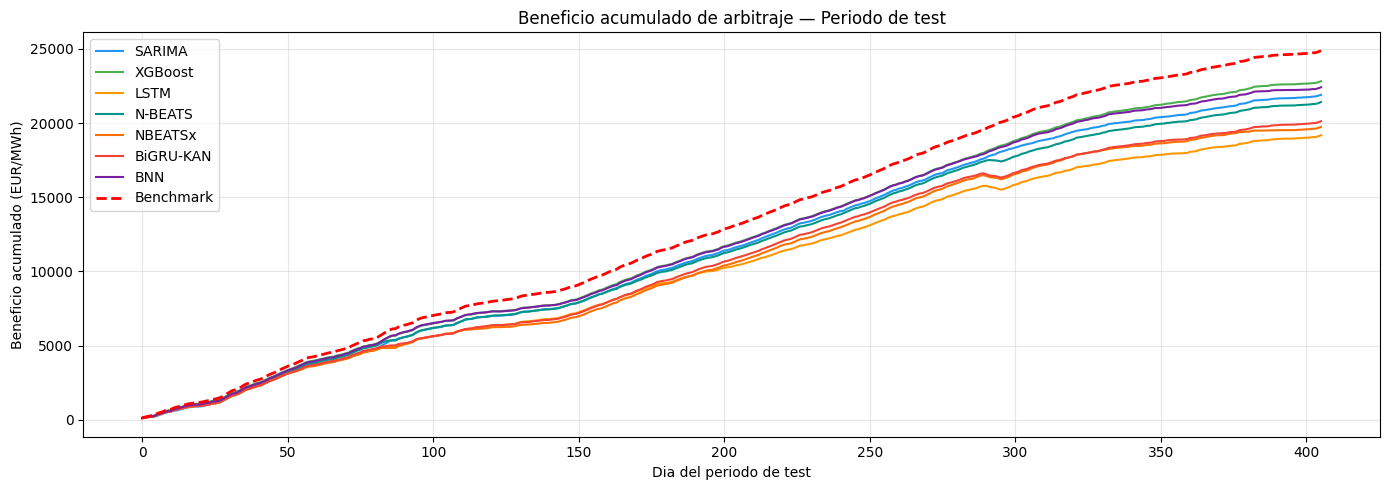

Grafico guardado como beneficio_acumulado.png


In [10]:
# Grafico 2 — Beneficio acumulado a lo largo del tiempo
fig, ax = plt.subplots(figsize=(14, 5))

for i, modelo in enumerate(modelos_lista):
    beneficio_acumulado = np.cumsum(resultados_arbitraje[modelo]['B_diario'])
    ax.plot(range(len(benchmark_diario)), beneficio_acumulado,
            label=modelo, color=colores[i], linewidth=1.5)

ax.plot(range(len(benchmark_diario)), np.cumsum(benchmark_diario),
        label='Benchmark', color='red', linewidth=2, linestyle='--')

ax.set_title('Beneficio acumulado de arbitraje — Periodo de test', fontsize=12)
ax.set_xlabel('Dia del periodo de test')
ax.set_ylabel('Beneficio acumulado (EUR/MWh)')
ax.legend(loc='upper left')
ax.grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig('beneficio_acumulado.png', dpi=150, bbox_inches='tight')
plt.show()
print('Grafico guardado como beneficio_acumulado.png')

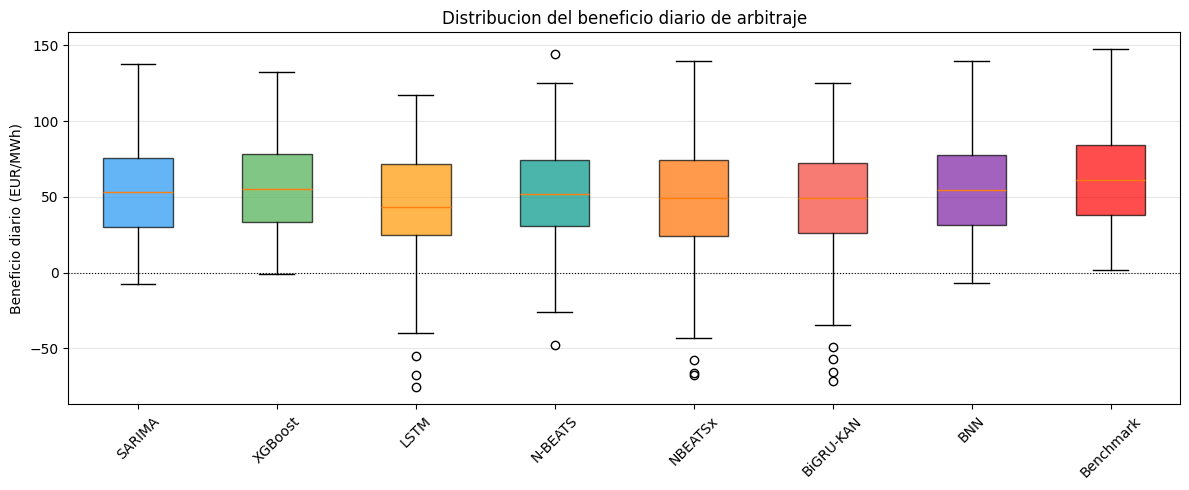

Grafico guardado como boxplot_beneficio_diario.png


In [11]:
# Grafico 3 — Boxplot de distribucion del beneficio diario
fig, ax = plt.subplots(figsize=(12, 5))

datos_box = [resultados_arbitraje[m]['B_diario'] for m in modelos_lista]
datos_box.append(benchmark_diario)
etiquetas = modelos_lista + ['Benchmark']

bp = ax.boxplot(datos_box, labels=etiquetas, patch_artist=True)
for patch, color in zip(bp['boxes'], colores[:len(modelos_lista)] + ['red']):
    patch.set_facecolor(color)
    patch.set_alpha(0.7)

ax.set_title('Distribucion del beneficio diario de arbitraje', fontsize=12)
ax.set_ylabel('Beneficio diario (EUR/MWh)')
ax.tick_params(axis='x', rotation=45)
ax.axhline(0, color='black', linewidth=0.8, linestyle=':')
ax.grid(True, alpha=0.3, axis='y')

plt.tight_layout()
plt.savefig('boxplot_beneficio_diario.png', dpi=150, bbox_inches='tight')
plt.show()
print('Grafico guardado como boxplot_beneficio_diario.png')

---
## 7. Exportar resultados para el Capítulo 7

In [12]:
# Exportar tabla comparativa
tabla_arb.to_csv('resultados_arbitraje.csv')
print('Tabla exportada como resultados_arbitraje.csv')

# Exportar beneficios diarios por modelo
df_beneficios = pd.DataFrame({'fecha': dias_validos})
for modelo, res in resultados_arbitraje.items():
    df_beneficios[modelo] = res['B_diario']
df_beneficios['Benchmark'] = benchmark_diario
df_beneficios.to_csv('beneficios_diarios.csv', index=False)
print('Beneficios diarios exportados como beneficios_diarios.csv')

print('\nListo para el Capitulo 7 — Resultados')
print('\nResumen final:')
print(tabla_arb[['B_total (EUR/MWh)', 'Eficiencia (%)']].to_string())

Tabla exportada como resultados_arbitraje.csv
Beneficios diarios exportados como beneficios_diarios.csv

Listo para el Capitulo 7 — Resultados

Resumen final:
                      B_total (EUR/MWh)  Eficiencia (%)
Modelo                                                 
SARIMA                         21900.87            88.0
XGBoost                        22822.31            91.7
LSTM                           19183.07            77.1
N-BEATS                        21417.17            86.1
NBEATSx                        19744.72            79.4
BiGRU-KAN                      20129.61            80.9
BNN                            22415.80            90.1
Benchmark (perfecta)           24877.48           100.0
